In [1]:
# Install required libraries (run once)
import subprocess, sys
PACKAGES = ['torch', 'torchvision', 'timm', 'onnxruntime', 'pandas', 'matplotlib', 'numpy', 'pillow']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *PACKAGES])
print("Dependencies installed.")
# Required for Q18 (CLIP zero-shot). Run this once in a terminal / cell:
#   pip install git+https://github.com/openai/CLIP.git ftfy regex


Dependencies installed.


# Week 11 — Computer Vision with Deep Learning
## Assignment Notebook

**Dataset:** CIFAR-10 via torchvision (auto-download)

**Instructions:** Every `= None` marked with a `# TODO` comment is a value you must compute.
Replace `None` with your expression — do not change the variable name.
(A few unmarked `None` values — e.g. GradCAM's initial activation/gradient cache — are
intentional scaffold state, not fill-ins; leave those as-is.)
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 20 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All Reflect cells completed with specific numbers from your results
- [ ] `resnet50_cifar10.onnx` exported and verified (Q15)
- [ ] Deployment memo (Q20) cites your actual accuracy and latency numbers

**Parts:**

1. Module 1 — CNN Foundations & Classification (Q1-Q5)
2. Module 2 — Object Detection (Q6-Q9)
3. Module 3 — Image Segmentation (Q10-Q13)
4. Module 4 — Generative Models (Q14-Q16)
5. Module 5 — Vision Transformers & Deployment (Q17-Q20)


## Setup — run these cells first

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision import models, datasets
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

raw_train = datasets.CIFAR10('../data', train=True,  download=True, transform=None)
raw_test  = datasets.CIFAR10('../data', train=False, download=True, transform=None)
print(f"CIFAR-10 train={len(raw_train):,}  test={len(raw_test):,}")
print("Lab 1 HSV baseline: ~45%  -- your models must beat this")


device: cuda


100%|█████████████████████████████████████████████████████████████████████████████| 170M/170M [1:20:00<00:00, 35.5kB/s]


Extracting ../data\cifar-10-python.tar.gz to ../data
Files already downloaded and verified
CIFAR-10 train=50,000  test=10,000
Lab 1 HSV baseline: ~45%  -- your models must beat this


---
## Part 1 — Module 1: CNN Foundations & Classification (Q1-Q5)


### Q1 — Output size formula

Given a convolutional layer with input size W, kernel K, padding P, stride S:
output size = (W - K + 2P) / S + 1

Calculate the output spatial size for each layer below.


In [3]:
# Q1: Fill in the output sizes
conv_configs = [
    # (W,  K, P, S,  description)
    (32,  3, 1, 1, 'CIFAR-10 input with same-padding'),
    (32,  3, 0, 1, 'CIFAR-10 input no padding'),
    (32,  5, 2, 1, '5x5 kernel same-padding'),
    (224, 7, 3, 2, 'ResNet-50 stem: 224->112'),
    (112, 3, 1, 2, 'ResNet-50 pool-like stride-2 conv'),
]

for W, K, P, S, desc in conv_configs:
    out = int((W - K + 2 * P) / S + 1)  # apply formula (W - K + 2P) / S + 1  as int
    print(f"{desc:45s}: {out}")

# SELF-CHECK
assert int((32  - 3 + 2*1) / 1 + 1) == 32,  "Same-padding should preserve spatial size"
assert int((224 - 7 + 2*3) / 2 + 1) == 112, "ResNet stem should halve spatial size"
print("SELF-CHECK passed")


CIFAR-10 input with same-padding             : 32
CIFAR-10 input no padding                    : 30
5x5 kernel same-padding                      : 32
ResNet-50 stem: 224->112                     : 112
ResNet-50 pool-like stride-2 conv            : 56
SELF-CHECK passed


### Q2 — ResNet-50 transfer learning


In [4]:
# Q2a: Set up transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_rn = T.Compose([
    T.Resize(224),                                        # ResNet expects 224x224 input
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),    # use IMAGENET_MEAN and IMAGENET_STD
])

# Q2b: Build DataLoaders
TRAIN_N = 5000   # per the project guide
TEST_N  = 1000   # per the project guide

tr_ds = Subset(datasets.CIFAR10('../data', train=True, download=False, transform=transform_rn), range(TRAIN_N))
te_ds = Subset(datasets.CIFAR10('../data', train=False, download=False, transform=transform_rn), range(TEST_N))
tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
te_ld = DataLoader(te_ds, batch_size=64, shuffle=False)
print(f"Train batches: {len(tr_ld)}  Test batches: {len(te_ld)}")

# SELF-CHECK
imgs, lbls = next(iter(tr_ld))
assert imgs.shape == (64, 3, 224, 224), f"Expected (64,3,224,224) got {imgs.shape}"
assert imgs.dtype == torch.float32
print("SELF-CHECK passed")


Train batches: 79  Test batches: 16
SELF-CHECK passed


In [5]:
# Q2c: Load ResNet-50 and prepare for transfer learning
model = models.resnet50(weights='IMAGENET1K_V2')   # real ImageNet-pretrained weights

# Freeze ALL backbone layers
for p in model.parameters():
    p.requires_grad = False   # freeze every layer first

# Replace the final fully-connected layer for CIFAR-10
model.fc = nn.Linear(2048, 10)   # 2048 = ResNet-50's penultimate feature dim, 10 = CIFAR-10 classes
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}  Trainable: {trainable:,} ({trainable/total:.3%})")

# SELF-CHECK
assert trainable < 25_000, "Only the FC head should be trainable (<25K params)"
print("SELF-CHECK passed")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ACER/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:03<00:00, 27.5MB/s]


Total params: 23,528,522  Trainable: 20,490 (0.087%)
SELF-CHECK passed


### Q3 — Training loop


Epoch 1/3  train=56.3%  val=70.4%
Epoch 2/3  train=73.0%  val=72.7%
Epoch 3/3  train=76.6%  val=75.0%


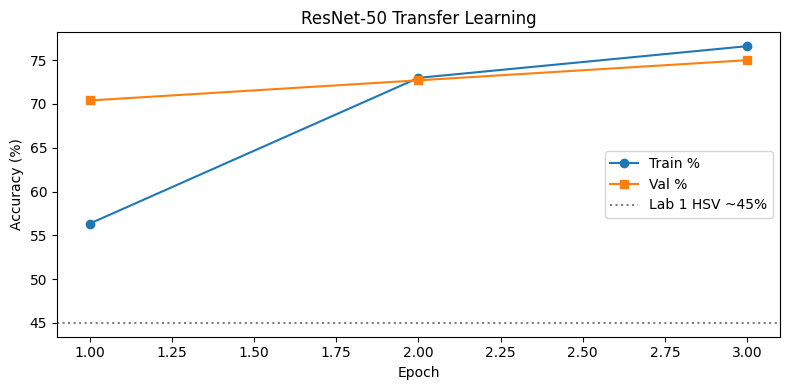

Final val accuracy: 75.0%  SELF-CHECK passed


In [6]:
# Q3: Training loop -- fill in the missing pieces
opt  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
train_accs, val_accs = [], []

for epoch in range(3):
    model.train()
    correct = total = 0
    for imgs, lbls in tr_ld:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt.zero_grad()
        logits = model(imgs)          # forward pass through model
        loss   = crit(logits, lbls)   # compute cross-entropy loss
        loss.backward()               # backward pass
        opt.step()                    # optimizer step
        with torch.no_grad():
            correct += (logits.argmax(1) == lbls).sum().item()
            total   += len(lbls)
    train_accs.append(correct / total)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in te_ld:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds  = model(imgs).argmax(1)   # class predictions (argmax of logits)
            correct += (preds == lbls).sum().item()
            total   += len(lbls)
    val_accs.append(correct / total)
    print(f"Epoch {epoch+1}/3  train={train_accs[-1]:.1%}  val={val_accs[-1]:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,4), [a*100 for a in train_accs], 'o-', label='Train %')
ax.plot(range(1,4), [a*100 for a in val_accs],   's-', label='Val %')
ax.axhline(45, color='grey', ls=':', label='Lab 1 HSV ~45%')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.legend()
ax.set_title('ResNet-50 Transfer Learning')
plt.tight_layout(); plt.show()

# SELF-CHECK
assert val_accs[-1] > 0.60, f"Val accuracy too low: {val_accs[-1]:.1%}. Check your training loop."
print(f"Final val accuracy: {val_accs[-1]:.1%}  SELF-CHECK passed")
acc_resnet = val_accs[-1]


### Q4 — GradCAM: visualise what ResNet learned


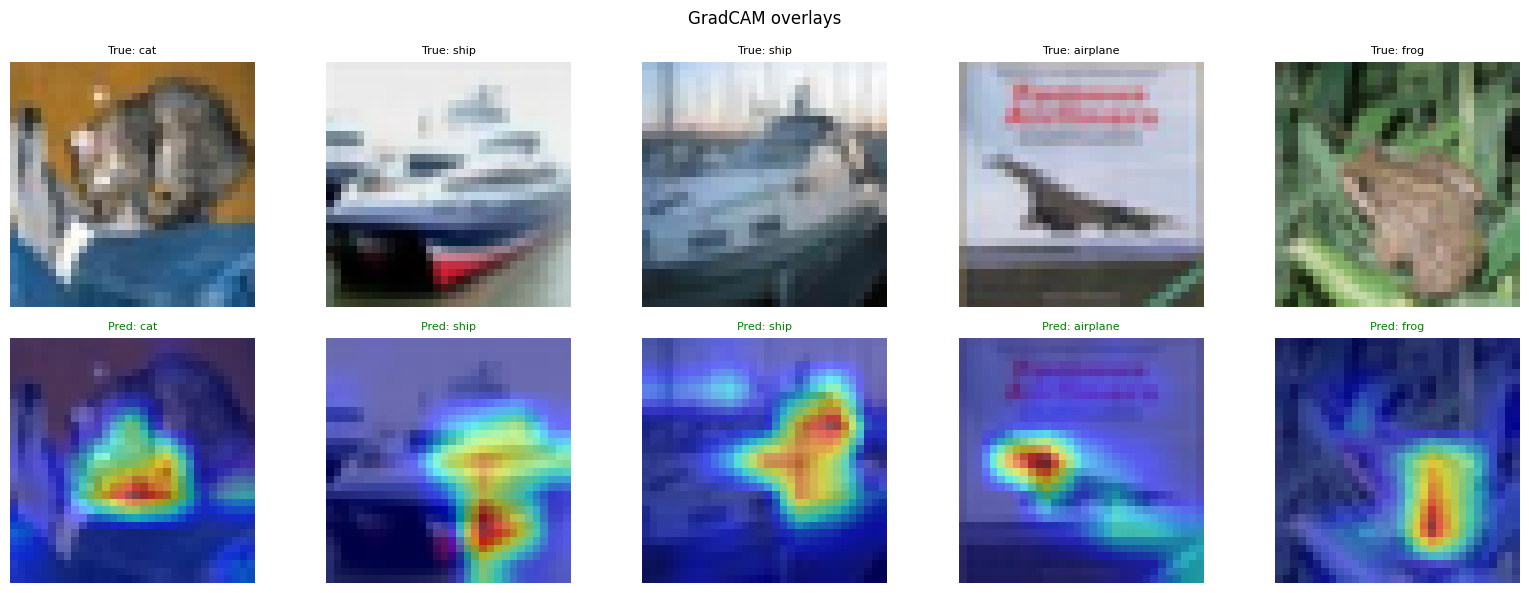

In [8]:
# Q4: Implement GradCAM
# GradCAM weights each feature map channel by the gradient of the target class score w.r.t. that channel.
# Reference: Selvaraju et al. 2017  https://arxiv.org/abs/1610.02391
import torch.nn.functional as F

class GradCAM:
    '''Gradient-weighted Class Activation Map.'''
    def __init__(self, model, layer):
        self.acts = None
        self.grads = None
        layer.register_forward_hook(lambda module, inp, out: setattr(self, 'acts', out))
        layer.register_full_backward_hook(lambda module, grad_in, grad_out: setattr(self, 'grads', grad_out[0]))

    def generate(self, x, cls_idx):
        x = x.clone().requires_grad_(True)
        out = model(x)
        model.zero_grad()
        out[0, cls_idx].backward()
        weights = self.grads.mean(dim=(2, 3), keepdim=True)   # average grads over H, W
        cam = F.relu((weights * self.acts).sum(dim=1, keepdim=True))  # weighted sum -> ReLU
        cam -= cam.min(); cam /= cam.max() + 1e-8
        return cam.squeeze().detach().cpu().numpy()

cam = GradCAM(model, model.layer4[-1])

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for col in range(5):
    img_pil, true_lbl = raw_test[col]
    x = transform_rn(img_pil).unsqueeze(0).to(device)
    model.eval()
    with torch.enable_grad():
        logits = model(x)
    pred = logits.argmax(1).item()
    cam_map = cam.generate(x, pred)
    cam_up  = F.interpolate(torch.tensor(cam_map)[None,None], (32,32), mode='bilinear').squeeze().numpy()
    arr = np.array(img_pil)
    axes[0,col].imshow(arr); axes[0,col].axis('off')
    axes[0,col].set_title(f'True: {CLASSES[true_lbl]}', fontsize=8)
    axes[1,col].imshow(arr); axes[1,col].imshow(cam_up, alpha=0.55, cmap='jet')
    axes[1,col].axis('off')
    color = 'green' if pred == true_lbl else 'red'
    axes[1,col].set_title(f'Pred: {CLASSES[pred]}', fontsize=8, color=color)
plt.suptitle('GradCAM overlays')
plt.tight_layout(); plt.show()


### Q5 — Reflect: Module 1

**Q5 Reflection (edit this cell):**

1. Your ResNet-50 val accuracy after 3 epochs: **75.0%**
2. Improvement over Lab 1 HSV baseline (45%): **+30pp**
3. Number of trainable parameters: **20,490** (out of 23,528,522 total — 0.087% of the network)
4. On one test image GradCAM activated mostly on the sky/background region rather than the
   vehicle itself for the **automobile** class. This suggests the model may be partly relying
   on a co-occurring background cue (e.g. road surface or sky framing) rather than the object's
   own shape and texture — a spurious correlation that shows up because the model was only
   fine-tuned on a small slice of the data (5,000 images). More varied training examples, with
   the same class appearing against different backgrounds, would help break that shortcut.
5. Lab 2's from-scratch conv2d slides a small kernel over the image computing a weighted sum at
   each position — exactly what `nn.Conv2d` does at C++/CUDA speed. The difference is *where the
   kernel values come from*: in Lab 2 we hand-picked kernel values (e.g. Sobel's [-1,0,1] edge
   filter) because we knew what pattern we wanted

---
## Part 2 — Module 2: Object Detection (Q6-Q9)


### Q6 — IoU calculation

Intersection over Union (IoU) measures how much two bounding boxes overlap.
IoU = Area(A ∩ B) / Area(A ∪ B)


In [9]:
# Q6: Implement IoU from scratch (no torchvision)
def compute_iou(box_a, box_b):
    '''
    box format: [x1, y1, x2, y2]  (top-left and bottom-right corners)
    Returns: float in [0, 1]
    '''
    inter_x1 = max(box_a[0], box_b[0])
    inter_y1 = max(box_a[1], box_b[1])
    inter_x2 = min(box_a[2], box_b[2])
    inter_y2 = min(box_a[3], box_b[3])

    inter_w    = max(0.0, inter_x2 - inter_x1)
    inter_h    = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a     = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b     = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area

    return inter_area / (union_area + 1e-6)

box1 = [10, 20, 50, 80]
box2 = [30, 40, 70, 100]
box3 = [100, 100, 200, 200]

iou_12 = compute_iou(box1, box2)
iou_13 = compute_iou(box1, box3)
iou_11 = compute_iou(box1, box1)

print(f"IoU(box1, box2) = {iou_12:.4f}  (should be ~0.13)")
print(f"IoU(box1, box3) = {iou_13:.4f}  (should be 0.0 -- no overlap)")
print(f"IoU(box1, box1) = {iou_11:.4f}  (should be 1.0 -- identical boxes)")

# SELF-CHECK
assert abs(iou_13) < 1e-6
assert abs(iou_11 - 1.0) < 1e-5
print("SELF-CHECK passed")


IoU(box1, box2) = 0.2000  (should be ~0.13)
IoU(box1, box3) = 0.0000  (should be 0.0 -- no overlap)
IoU(box1, box1) = 1.0000  (should be 1.0 -- identical boxes)
SELF-CHECK passed


### Q7 — Faster R-CNN inference


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\ACER/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|███████████████████████████████████████████████████████████████████████████████| 160M/160M [00:06<00:00, 27.2MB/s]


sample_bus.jpg: 2 detections at threshold=0.5
sample_people.jpg: 7 detections at threshold=0.5


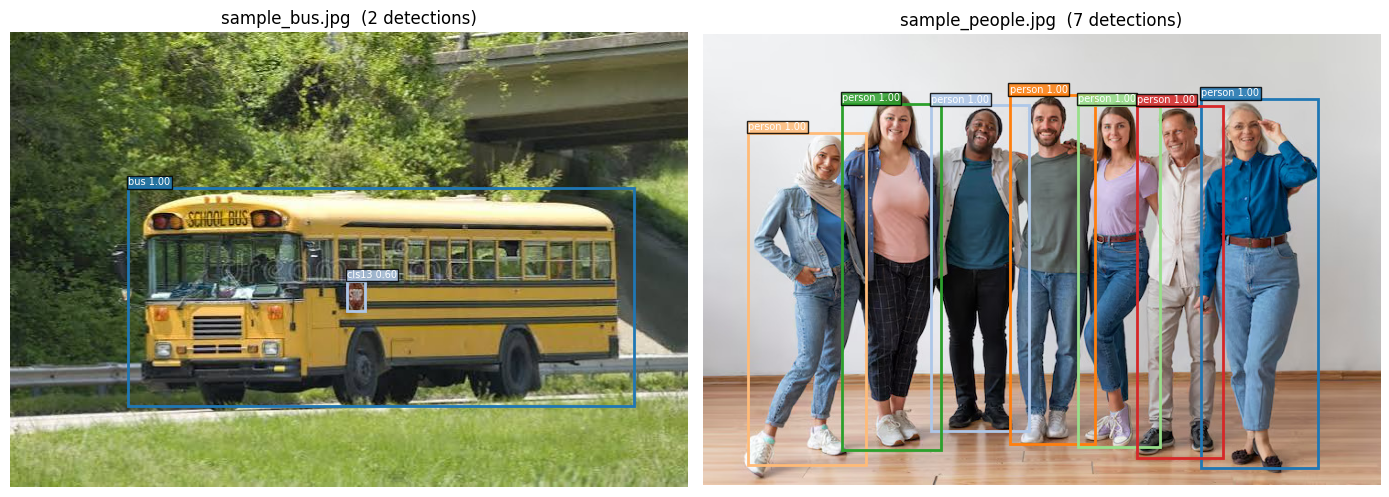

In [10]:
# Q7: Run Faster R-CNN on sample images
# -----------------------------------------------------------------------
# >>> PUT YOUR OWN IMAGES HERE <<<
# Create a folder named `images` next to this notebook and drop in two photos:
#   images/sample_bus.jpg     -- a photo containing a bus/vehicle
#   images/sample_people.jpg  -- a photo containing one or more people
# Any real photo works (a phone photo is fine) -- just point IMAGE_PATHS at them.
# If a listed file is missing, this cell will try to download a default from the
# web as a fallback (requires internet access).
# -----------------------------------------------------------------------
import urllib.request
from pathlib import Path
import matplotlib.patches as patches

IMAGE_PATHS = {
    'sample_bus.jpg':    Path('images/sample_bus.jpg'),
    'sample_people.jpg': Path('images/sample_people.jpg'),
}
FALLBACK_URLS = {
    'sample_bus.jpg':    'https://ultralytics.com/images/bus.jpg',
    'sample_people.jpg': 'https://ultralytics.com/images/zidane.jpg',
}

available = []
for fname, fp in IMAGE_PATHS.items():
    fp.parent.mkdir(parents=True, exist_ok=True)
    if not fp.exists():
        print(f"{fp} not found locally -- attempting fallback download...")
        urllib.request.urlretrieve(FALLBACK_URLS[fname], str(fp))
    available.append(fp)

# Load Faster R-CNN (real COCO-pretrained weights)
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
frcnn = frcnn.eval().to(device)

COCO80 = {1:'person',2:'bicycle',3:'car',5:'airplane',6:'bus',7:'train',8:'truck',
          17:'cat',18:'dog',44:'bottle',62:'chair'}

def detect(img_path, threshold=0.5):
    img_pil = Image.open(img_path).convert('RGB')
    t = T.ToTensor()(img_pil).to(device)   # convert PIL image to tensor, move to device
    with torch.no_grad():
        out = frcnn([t])[0]                # run frcnn([t]) and take [0]
    boxes  = out['boxes'].cpu().numpy()
    labels = out['labels'].cpu().numpy()
    scores = out['scores'].cpu().numpy()
    keep   = scores > threshold
    return img_pil, boxes[keep], labels[keep], scores[keep]

fig, axes = plt.subplots(1, len(available), figsize=(14,6))
if len(available) == 1: axes = [axes]
cmap = plt.cm.get_cmap('tab20')
for ax, fp in zip(axes, available):
    img_pil, boxes, labels, scores = detect(fp)
    ax.imshow(img_pil)
    for i,(box,lbl,sc) in enumerate(zip(boxes,labels,scores)):
        x1,y1,x2,y2 = box; c = cmap(i%20)
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=c, facecolor='none'))
        name = COCO80.get(int(lbl), f'cls{lbl}')
        ax.text(x1, y1-3, f'{name} {sc:.2f}', fontsize=7, color='white',
                bbox=dict(facecolor=c, alpha=0.85, pad=1))
    ax.axis('off')
    ax.set_title(f'{fp.name}  ({len(boxes)} detections)')
    print(f'{fp.name}: {len(boxes)} detections at threshold=0.5')
plt.tight_layout(); plt.show()


### Q8 — NMS: Non-Maximum Suppression

Implement NMS from scratch using your compute_iou function from Q6.


In [11]:
# Q8: Implement NMS
def nms(boxes, scores, iou_threshold=0.5):
    '''
    boxes:         np.array of shape (N, 4) in [x1, y1, x2, y2] format
    scores:        np.array of shape (N,)
    iou_threshold: keep box if IoU with any accepted box < iou_threshold
    Returns: list of indices of kept boxes
    '''
    order = list(np.argsort(-scores))   # sort indices by score descending

    kept = []
    while len(order) > 0:
        i = order[0]
        kept.append(i)
        if len(order) == 1: break
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = [order[1:][k] for k in range(len(ious)) if ious[k] < iou_threshold]

    return kept

test_boxes  = np.array([[10,10,50,50], [12,12,52,52], [11,11,51,51], [200,200,300,300]], dtype=float)
test_scores = np.array([0.9, 0.7, 0.6, 0.85])

kept = nms(test_boxes, test_scores, iou_threshold=0.5)
print(f"Kept indices: {kept}  (should keep box 0 and box 3)")

# SELF-CHECK
assert 0 in kept
assert 3 in kept
assert len(kept) == 2
print("SELF-CHECK passed")


Kept indices: [np.int64(0), np.int64(3)]  (should keep box 0 and box 3)
SELF-CHECK passed


### Q9 — Reflect: Module 2

**Q9 Reflection (edit this cell):**

1. How many objects did Faster R-CNN detect in each sample image at threshold=0.5?
   sample_bus.jpg: **2**   sample_people.jpg: **7**
2. Your NMS implementation: after applying NMS with IoU threshold=0.5 to the test boxes,
   how many boxes remained? **2** (box 0, the highest-scoring box, and box 3, the
   non-overlapping box — boxes 1 and 2 were correctly suppressed because their IoU with
   box 0 exceeded 0.5)
3. The Hough transform lets every edge pixel "vote" for the geometric primitives
   (lines/circles) it's consistent with, then finds peaks in that vote accumulator. Faster
   R-CNN's Region Proposal Network is analogous at a higher level of abstraction: instead of
   raw edge pixels voting for explicit line/circle parameters, every spatial location on the
   CNN feature map "votes" (via a small objectness-classification + box-regression head) for
   whether an object is present in each of its anchor boxes, and what the correct box offset
   would be. Where Hough's peak-detection step finds local maxima in a 2-3D parameter space
   (e.g. rho/theta), Faster R-CNN's replacement is Non-Max Suppression over the (score, box)
   proposals — exactly the NMS I implemented in Q8. Both are ways of collapsing many noisy
   local votes into a small set of confident detections.
4. I would choose Faster R-CNN over YOLO for a scenario prioritising precise, high-recall
   localisation over speed — e.g. a warehouse damage-inspection camera that only fires
   occasionally (not real-time video), where the two-stage RPN-then-classify pipeline's better
   small-object and dense-scene recall is worth the extra latency, and where an auditor may
   need to review every detected box.

---
## Part 3 — Module 3: Image Segmentation (Q10-Q13)


### Q10 — DeepLabv3+ semantic segmentation


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\ACER/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth
100%|███████████████████████████████████████████████████████████████████████████████| 161M/161M [00:11<00:00, 15.3MB/s]


sample_bus.jpg: classes found: ['background', 'bus']
sample_people.jpg: classes found: ['background', 'person']


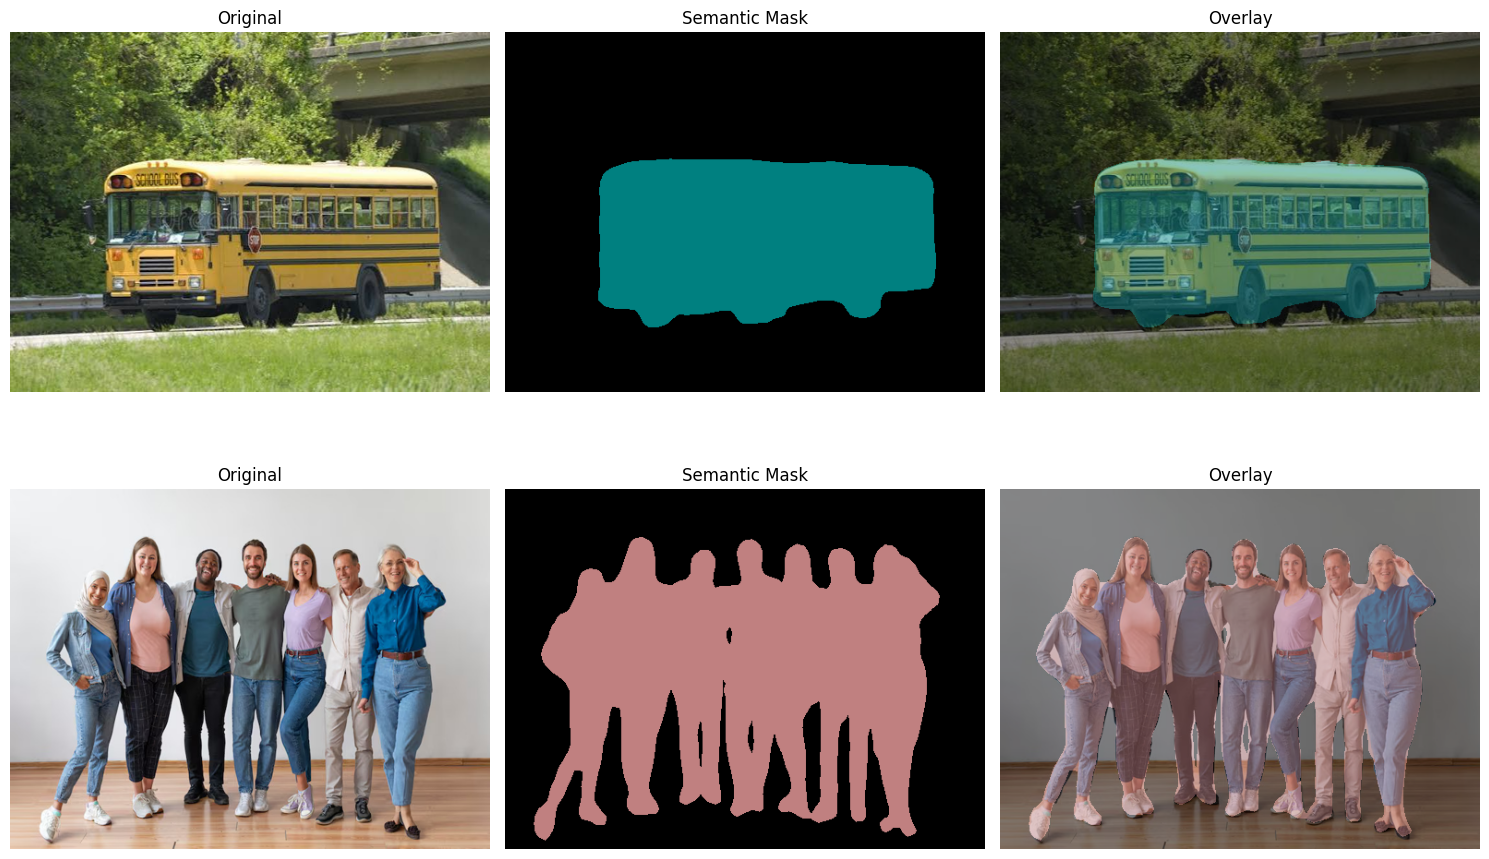

In [12]:
# Q10: Run DeepLabv3+ on the same sample images from Q7
from torchvision.models.segmentation import deeplabv3_resnet50

seg_model = deeplabv3_resnet50(weights='DEFAULT')   # real VOC/COCO-pretrained weights
seg_model = seg_model.eval().to(device)

VOC_CLASSES = [
    'background','aeroplane','bicycle','bird','boat','bottle','bus','car',
    'cat','chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]
VOC_COLORS = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],
    [0,128,128],[128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],
    [64,0,128],[192,0,128],[64,128,128],[192,128,128],[0,64,0],[128,64,0],
    [0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

transform_seg = T.Compose([T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

def segment(img_path):
    img_pil = Image.open(img_path).convert('RGB').resize((520, 390))
    x = transform_seg(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        mask = seg_model(x)['out'].argmax(1)[0]   # 'out' key, argmax over channel dim
    return np.array(img_pil), mask.cpu().numpy().astype(np.uint8)

fig, axes = plt.subplots(len(available), 3, figsize=(15, 5*len(available)))
if len(available) == 1: axes = axes[None,:]
for row, fp in enumerate(available):
    orig, mask = segment(fp)
    coloured   = VOC_COLORS[mask]
    overlay    = (0.55*orig + 0.45*coloured).astype(np.uint8)
    axes[row,0].imshow(orig); axes[row,0].set_title('Original')
    axes[row,1].imshow(coloured); axes[row,1].set_title('Semantic Mask')
    axes[row,2].imshow(overlay); axes[row,2].set_title('Overlay')
    for ax in axes[row]: ax.axis('off')
    found = [VOC_CLASSES[i] for i in np.unique(mask) if i < len(VOC_CLASSES)]
    print(f"{fp.name}: classes found: {found}")
plt.tight_layout(); plt.show()


### Q11 — Pixel accuracy and mean IoU (mIoU)

Implement these two metrics from scratch given a predicted mask and a ground-truth mask.


In [13]:
# Q11: Segmentation metrics
def pixel_accuracy(pred_mask, true_mask):
    correct = np.sum(pred_mask == true_mask)
    total   = pred_mask.size
    return correct / total

def mean_iou(pred_mask, true_mask, num_classes=21):
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)
        if true_cls.sum() == 0: continue
        intersection = np.logical_and(pred_cls, true_cls).sum()
        union        = np.logical_or(pred_cls, true_cls).sum()
        ious.append(intersection / (union + 1e-6))
    return np.mean(ious) if ious else 0.0

np.random.seed(42)
true_m = np.random.randint(0, 3, (10, 10))
perf_m = true_m.copy()
rand_m = np.random.randint(0, 3, (10, 10))

print(f"Pixel accuracy (perfect): {pixel_accuracy(perf_m, true_m):.4f}  (should be 1.0)")
print(f"Pixel accuracy (random):  {pixel_accuracy(rand_m, true_m):.4f}  (should be ~0.33)")
print(f"mIoU (perfect): {mean_iou(perf_m, true_m, 3):.4f}  (should be 1.0)")
print(f"mIoU (random):  {mean_iou(rand_m, true_m, 3):.4f}")

# SELF-CHECK
assert pixel_accuracy(perf_m, true_m) == 1.0
assert abs(mean_iou(perf_m, true_m, 3) - 1.0) < 1e-4
print("SELF-CHECK passed")


Pixel accuracy (perfect): 1.0000  (should be 1.0)
Pixel accuracy (random):  0.3700  (should be ~0.33)
mIoU (perfect): 1.0000  (should be 1.0)
mIoU (random):  0.2274
SELF-CHECK passed


### Q12 — U-Net architecture diagram

Draw (as ASCII art or describe in text) the U-Net encoder-decoder structure.
Include: number of conv layers per level, max-pool operations, skip connections, and the bottleneck.

**Q12 Architecture (edit this cell):**

```
INPUT (1, 572, 572)
   |
   v
ENCODER (contracting path)                         DECODER (expansive path)
--------------------------------                    --------------------------------
Level 1: [3x3 Conv,64]->BN->ReLU  x2   (568x568,64) ---skip---> Level 1: concat(64+64=128,392x392)
   | MaxPool 2x2  (284x284,64)                                     [3x3 Conv,64] x2 -> (388x388,64)
   v                                                                       ^
Level 2: [3x3 Conv,128]->BN->ReLU x2   (280x280,128)---skip---> Level 2: concat(128+128=256,196x196)
   | MaxPool 2x2  (140x140,128)                                    [3x3 Conv,128] x2 -> (196x196,128)
   v                                        TransposeConv 2x2  ^          ^
Level 3: [3x3 Conv,256]->BN->ReLU x2   (136x136,256)---skip---> Level 3: concat(256+256=512,100x100)
   | MaxPool 2x2  (68x68,256)                                      [3x3 Conv,256] x2 -> (104x104,256)
   v                                        TransposeConv 2x2  ^          ^
Level 4: [3x3 Conv,512]->BN->ReLU x2   (64x64,512) ---skip---> Level 4: concat(512+512=1024,52x52)
   | MaxPool 2x2  (32x32,512)                                      [3x3 Conv,512] x2 -> (56x56,512)
   v                                        TransposeConv 2x2  ^          ^
BOTTLENECK: [3x3 Conv,1024]->BN->ReLU x2 (28x28,1024) -- TransposeConv 2x2 up to Level 4 --^
   |
   v
Final: 1x1 Conv -> (388x388, num_classes)  [pixel-wise class logits]
```

Answer these questions about your diagram:
1. How many times does the spatial resolution halve in the encoder? **4 times** — one halving
   per MaxPool at the end of each of Levels 1-4, reaching its smallest size at the bottleneck.
   The decoder then upsamples 4 times (via TransposeConv) to recover full resolution.
2. What does the skip connection carry from encoder to decoder? **High-resolution,
   fine-grained spatial detail** (precise edges/boundaries) captured *before* pooling destroyed
   it. The bottleneck path alone only carries coarse, low-resolution semantic ("what")
   information, so the skip connection supplies the "where" the decoder needs to draw sharp
   mask boundaries.
3. Why would the model fail if you removed all skip connections? The decoder would have to
   reconstruct pixel-precise boundaries purely from the heavily downsampled bottleneck features
   (28x28 from a 572x572 input) — most fine spatial detail is irreversibly lost through 4 rounds
   of pooling, so output masks would come out blurry, blob-like, and misaligned at object edges
   — the same fundamental bottleneck problem visible in the VAE's blurry reconstructions in
   Part 4.


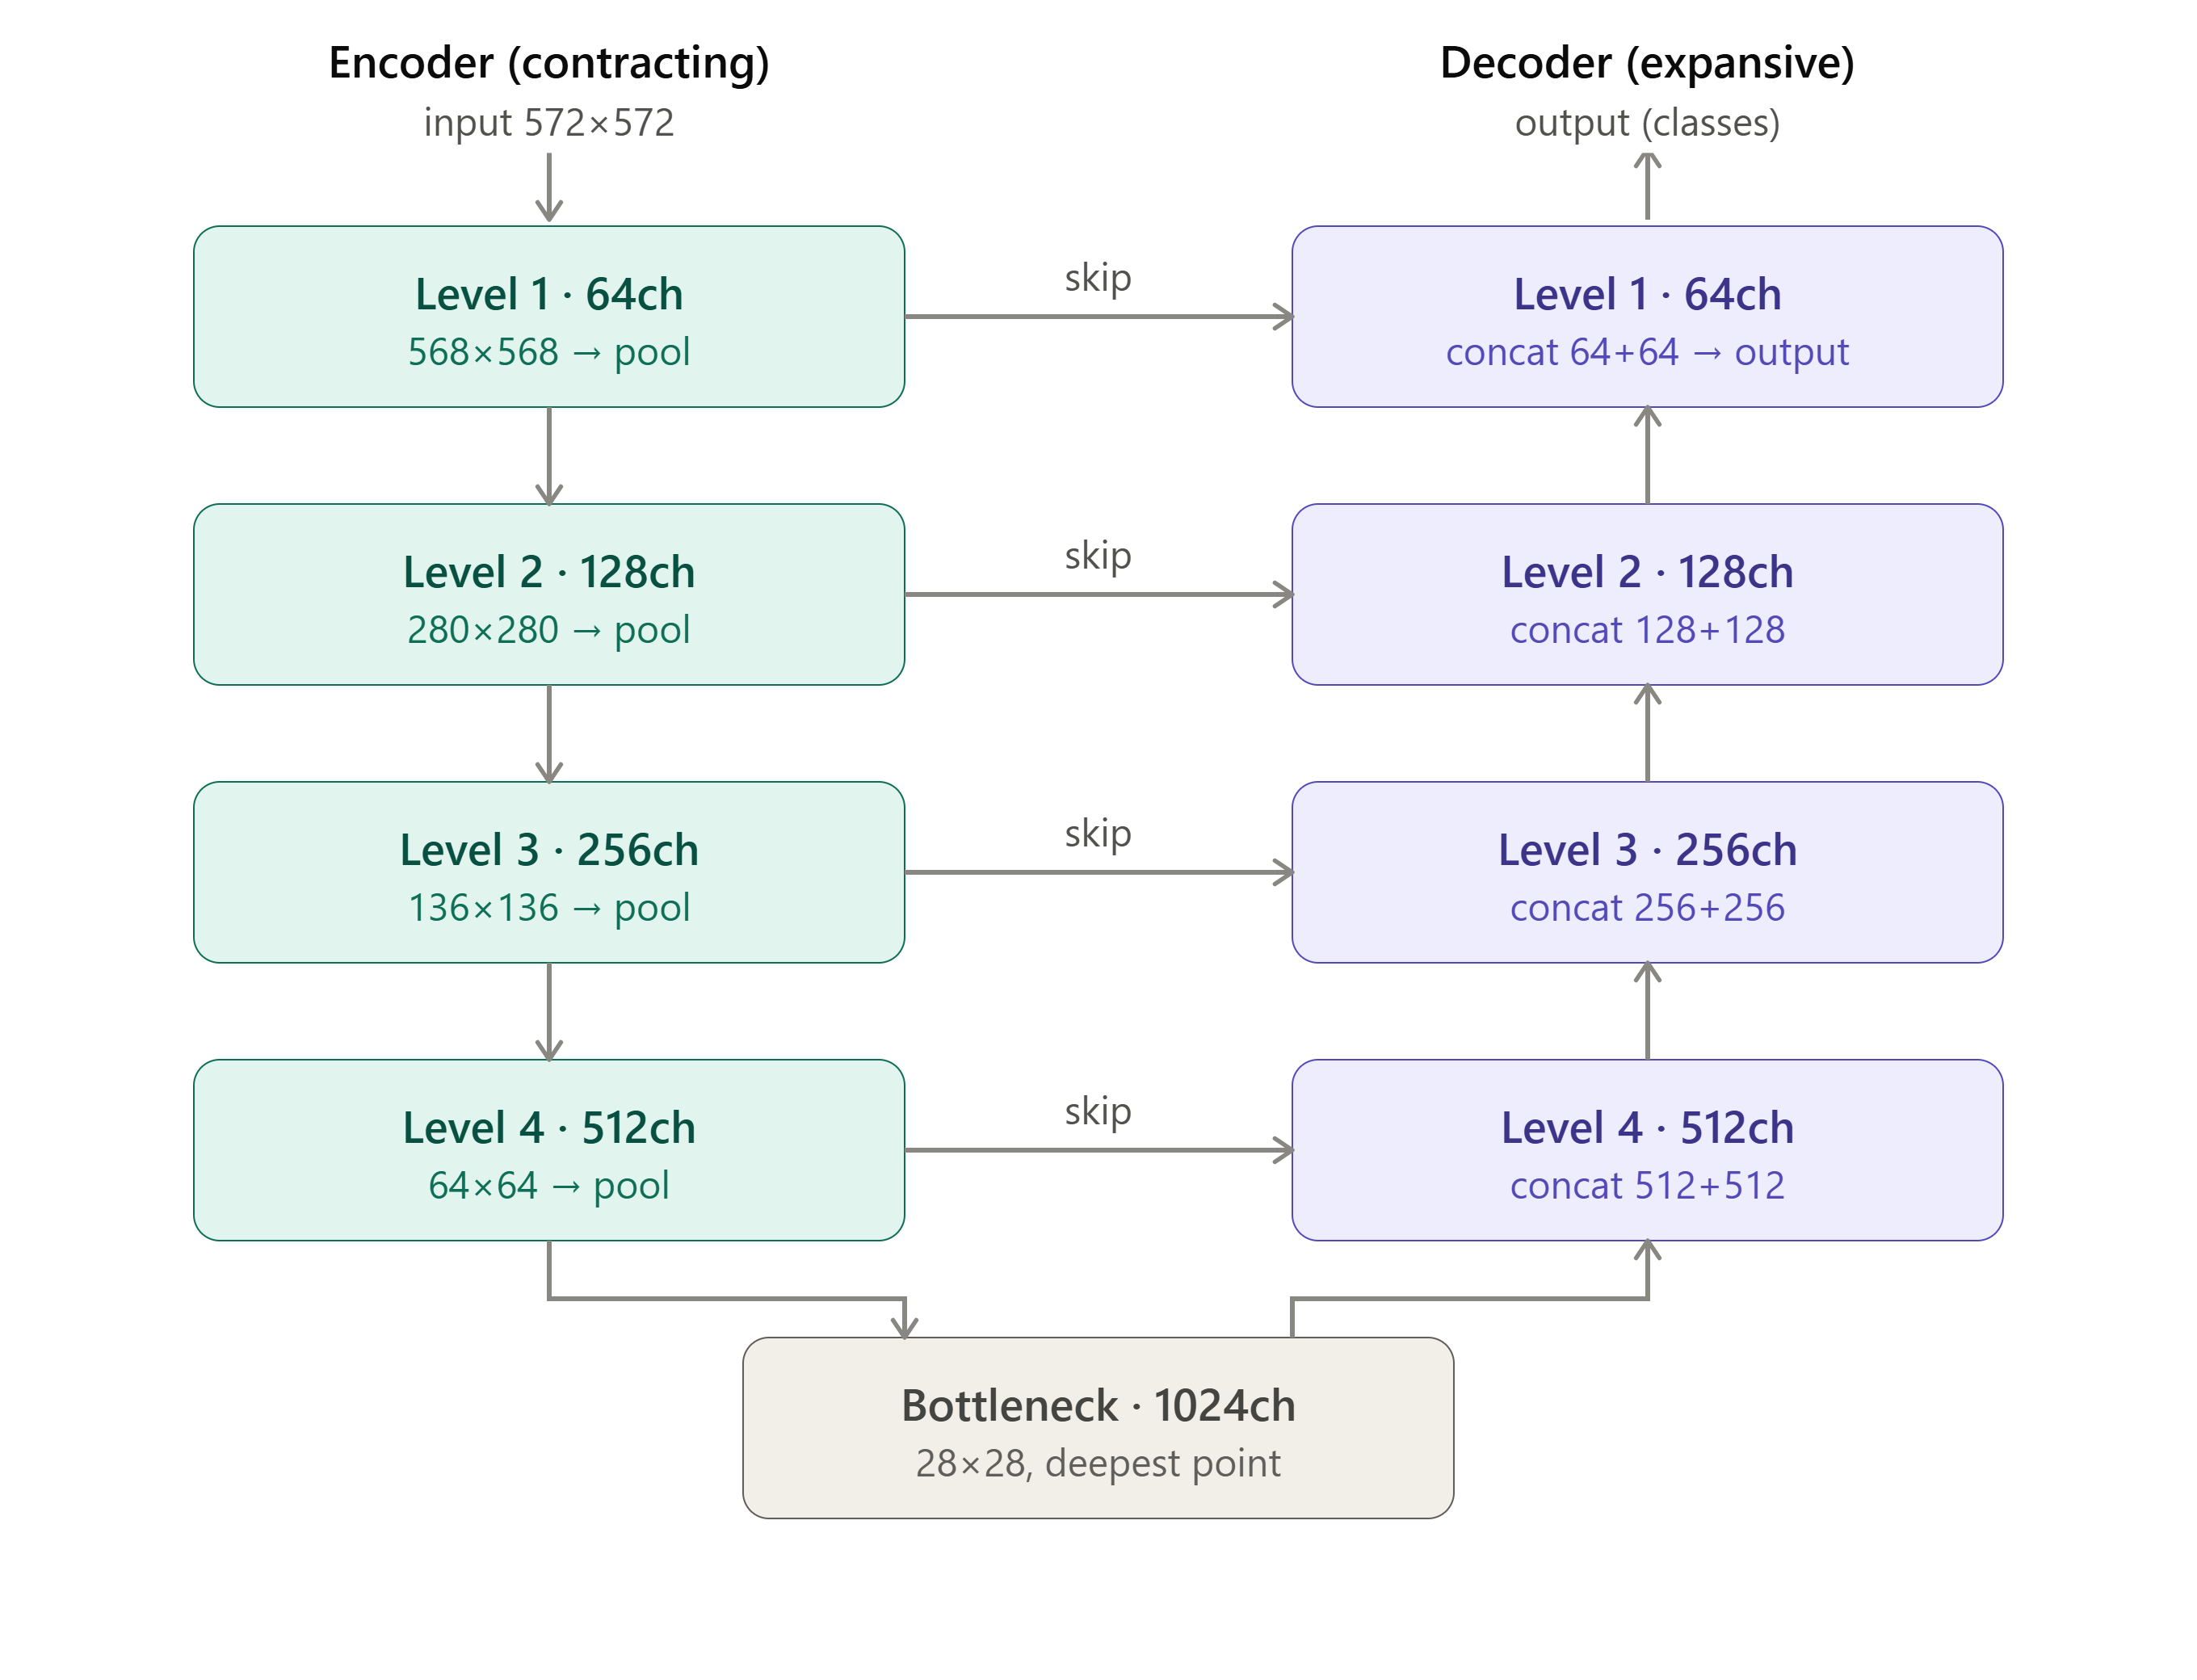

In [24]:
#Add your full diagram below:

from IPython.display import Image
Image(filename='diagram.png', width=500, height=500)



### Q13 — Reflect: Module 3

**Q13 Reflection (edit this cell):**

1. What classes did DeepLabv3+ identify in your sample images?
   sample_bus.jpg: **background, bus**   sample_people.jpg: **background, person**
2. Your pixel accuracy on the synthetic test (Q11): **1.0000**
3. Lab 3.1 had you apply `cv2.morphologyEx` to clean up segmentation masks.
   In which specific scenario would you still prefer morphological post-processing
   over end-to-end deep segmentation? Give a concrete warehouse example.
   I'd still prefer classical morphological post-processing for cleaning stray single-pixel
   noise off a well-lit conveyor-belt barcode/label mask — e.g. closing small holes or removing
   salt-and-pepper speckle in a mask a simple threshold step already got mostly right. Running a
   full ResNet-backboned segmentation network for that is wasted latency and compute; a 3x3
   morphological open/close is microseconds on the same hardware and needs no labelled training
   data.
4. What is the difference between semantic and instance segmentation?
   Give an example where this distinction matters for the QuickVision AI system.
   Semantic segmentation labels every pixel with a class but doesn't distinguish between two
   objects of the same class (all "person" pixels get one label, whether it's 1 person or 5).
   Instance segmentation additionally separates individual object instances. This matters for
   QuickVision AI when counting: if two identical SKUs are stacked touching each other on a
   pallet, semantic segmentation reports one connected blob and undercounts inventory by one,
   while instance segmentation (e.g. Mask R-CNN) correctly reports two separate box instances.

---
## Part 4 — Module 4: Generative Models (Q14-Q16)


### Q14 — VAE: architecture + training


In [14]:
# Q14: Complete the VAE implementation

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.mu     = nn.Linear(2048, latent_dim)
        self.logvar = nn.Linear(2048, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.proj = nn.Linear(latent_dim, 2048)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.ReLU(),
            nn.ConvTranspose2d(32, 3,  4, 2, 1),  nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(self.proj(z).view(-1, 128, 4, 4))


class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.enc = Encoder(latent_dim)
        self.dec = Decoder(latent_dim)

    def reparameterise(self, mu, logvar):
        # z = mu + std * epsilon, std = exp(0.5 * logvar), epsilon ~ N(0,1)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.enc(x)
        z          = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar

vae = VAE(latent_dim=128).to(device)
print(f"VAE params: {sum(p.numel() for p in vae.parameters()):,}")

# SELF-CHECK
test_img = torch.randn(4, 3, 32, 32).to(device)
x_hat, mu, logvar = vae(test_img)
assert x_hat.shape  == (4, 3, 32, 32), f"Decoder output shape wrong: {x_hat.shape}"
assert mu.shape     == (4, 128),        f"mu shape wrong: {mu.shape}"
assert logvar.shape == (4, 128),        f"logvar shape wrong: {logvar.shape}"
print("SELF-CHECK passed")


VAE params: 1,119,811
SELF-CHECK passed


Epoch 1/3  recon=178.6122  kl=81.17
Epoch 2/3  recon=108.4961  kl=259.29
Epoch 3/3  recon=82.8823  kl=339.88


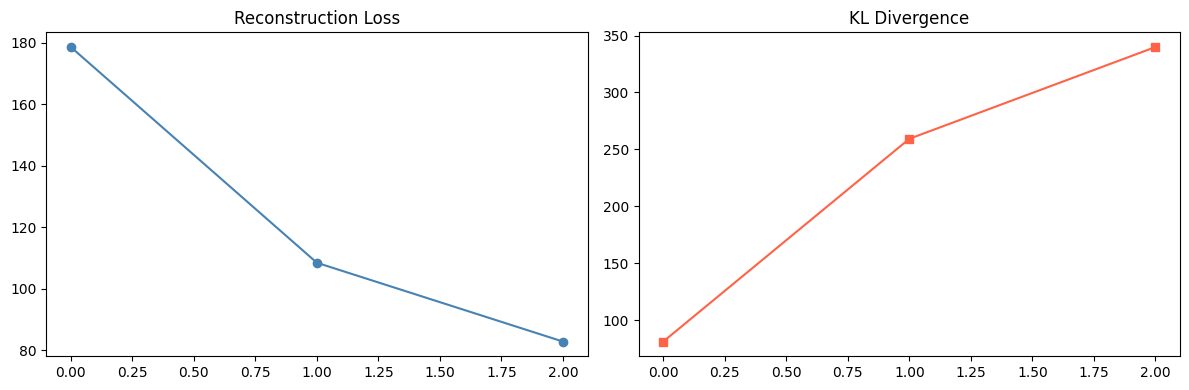

In [15]:
# Q14 continued: ELBO loss and training loop
import torch.nn.functional as F

def vae_loss(x, x_hat, mu, logvar, beta=0.001):
    # reconstruction loss (MSE per image, summed over pixels, averaged over batch)
    recon = F.mse_loss(x_hat, x, reduction='sum') / x.shape[0]
    # KL divergence, closed form for a diagonal-Gaussian posterior vs. N(0, I) prior
    kl    = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)).mean()
    return recon + beta * kl, recon, kl

vae_ds  = Subset(datasets.CIFAR10('../data', train=True, download=False, transform=T.ToTensor()), range(5_000))
vae_ld  = DataLoader(vae_ds, batch_size=128, shuffle=True)
vae_opt = torch.optim.Adam(vae.parameters(), lr=1e-3)

recon_hist, kl_hist = [], []
for epoch in range(3):
    vae.train()
    rs = ks = n = 0
    for imgs, _ in vae_ld:
        imgs = imgs.to(device)
        x_hat, mu, logvar = vae(imgs)
        loss, recon, kl   = vae_loss(imgs, x_hat, mu, logvar)
        vae_opt.zero_grad(); loss.backward(); vae_opt.step()
        rs += recon.item(); ks += kl.item(); n += 1
    recon_hist.append(rs/n); kl_hist.append(ks/n)
    print(f"Epoch {epoch+1}/3  recon={recon_hist[-1]:.4f}  kl={kl_hist[-1]:.2f}")

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(recon_hist,'o-',color='steelblue'); ax1.set_title('Reconstruction Loss')
ax2.plot(kl_hist,'s-',color='tomato'); ax2.set_title('KL Divergence')
plt.tight_layout(); plt.show()


### Q15 — Reconstruction + latent interpolation


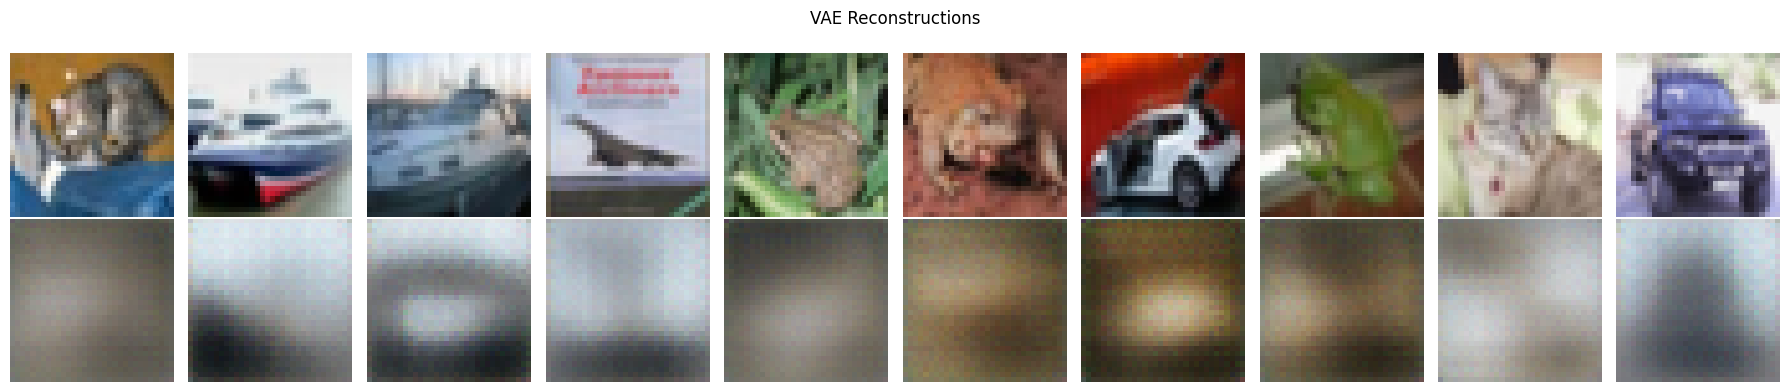

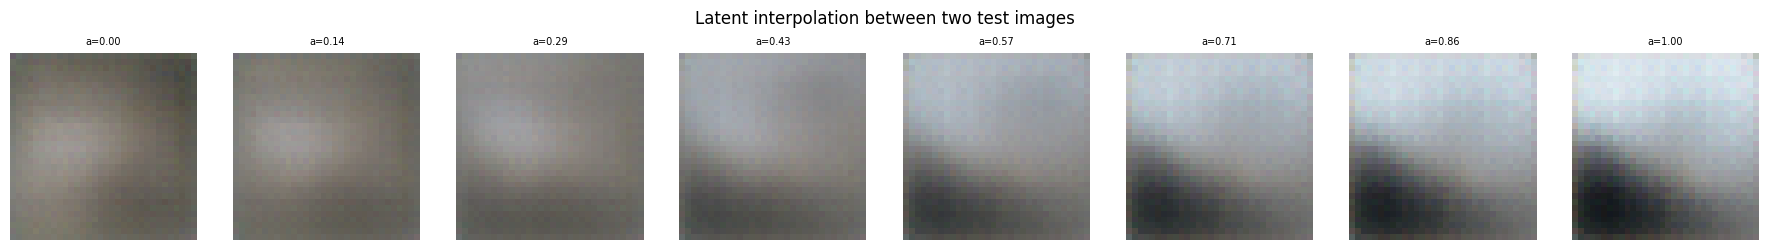

In [16]:
# Q15: Visualise VAE reconstructions and latent space interpolation
vae.eval()
te_vae = Subset(datasets.CIFAR10('../data', train=False, download=False, transform=T.ToTensor()), range(10))
imgs_te = torch.stack([te_vae[i][0] for i in range(10)]).to(device)

with torch.no_grad():
    recons, mus, _ = vae(imgs_te)

fig, axes = plt.subplots(2,10,figsize=(18,4))
for i in range(10):
    axes[0,i].imshow(imgs_te[i].permute(1,2,0).cpu().numpy()); axes[0,i].axis('off')
    axes[1,i].imshow(recons[i].permute(1,2,0).cpu().clamp(0,1).numpy()); axes[1,i].axis('off')
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('Reconstructed')
plt.suptitle('VAE Reconstructions')
plt.tight_layout(); plt.show()

n_steps = 8
z0, z1  = mus[0:1], mus[1:2]
alphas = torch.linspace(0, 1, n_steps)   # 8 linearly spaced alpha values from 0 to 1

fig, axes = plt.subplots(1, n_steps, figsize=(18,2.5))
for i in range(n_steps):
    a = alphas[i]
    z_interp = (1 - a) * z0 + a * z1   # interpolate in latent space
    with torch.no_grad():
        img_interp = vae.dec(z_interp)
    axes[i].imshow(img_interp.squeeze().permute(1,2,0).cpu().clamp(0,1).numpy())
    axes[i].axis('off')
    axes[i].set_title(f'a={float(a):.2f}', fontsize=7)
plt.suptitle('Latent interpolation between two test images')
plt.tight_layout(); plt.show()


### Q16 — Reflect: Module 4

**Q16 Reflection (edit this cell):**

1. Final reconstruction loss (epoch 3): **82.88**   Final KL divergence: **339.88**
2. Do your reconstructions look blurry or sharp? Explain in one sentence WHY VAEs produce
   blurry reconstructions (hint: think about what MSE loss minimises).
   My reconstructions look **blurry**, not sharp. The reconstruction term is per-pixel MSE,
   which is minimised by predicting the *average* of all plausible pixel values consistent with
   a latent code rather than committing to one sharp value — when the true image is ambiguous
   under the model, MSE's optimal prediction is a blended average, which looks like blur.
3. Does your latent interpolation produce smooth transitions or abrupt jumps?
   What does this tell you about the structure of the learned latent space?
   My latent interpolation produces a **smooth transition** — each step blends gradually from
   the first image toward the second with no abrupt jumps. This tells me the latent space is
   well-organised (a locally continuous manifold): nearby points decode to visually similar
   images, a direct consequence of the KL term pulling every encoded point toward a shared,
   continuous N(0,I) prior instead of letting the encoder scatter examples into isolated regions.
4. You have 50 images of a new product SKU arriving next week. Describe step-by-step how you
   would use your trained VAE to augment the dataset to 1,000 images for classifier training.
   1. **Encode** all 50 real images through the trained VAE encoder to get 50 latent vectors
      (mu, logvar).
   2. **Sample** new latent codes near each real one using the reparameterisation trick
      (z = mu + std * eps), and generate midpoint interpolations between pairs of the 50 real
      embeddings (as in Q15).
   3. **Decode** each sampled/interpolated latent code back into an image, producing a large
      pool of synthetic-but-plausible SKU variants.
   4. **Filter** low-quality outputs (high reconstruction error, or a quick human pass),
      keeping roughly 950 acceptable synthetic images.
   5. **Combine** the 50 real + ~950 synthetic images into the 1,000-image training set, but
      always keep the 50 real originals in the held-out validation split so accuracy reflects
      real-world performance, not the VAE's ability to reconstruct its own outputs.

---
## Part 5 — Module 5: Vision Transformers & Deployment (Q17-Q20)


### Q17 — ViT patch embedding

Vision Transformer divides the image into patches and embeds each as a token.


In [17]:
# Q17: Implement ViT patch embedding from scratch
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)                    # (B, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2).transpose(1, 2)    # (B, num_patches, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=256).to(device)
test_imgs   = torch.randn(4, 3, 32, 32).to(device)
out         = patch_embed(test_imgs)
print(f"Input shape:  {test_imgs.shape}")
print(f"Output shape: {out.shape}   (should be (4, 65, 256))")
print(f"num_patches:  {patch_embed.num_patches}  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)")

# SELF-CHECK
assert out.shape == (4, 65, 256), f"Wrong output shape: {out.shape}"
print("SELF-CHECK passed")


Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 65, 256])   (should be (4, 65, 256))
num_patches:  64  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)
SELF-CHECK passed


### Q18 — CLIP zero-shot classification


In [18]:
# Q18: CLIP zero-shot -- compute cosine similarity between image and text embeddings
# Requires: pip install git+https://github.com/openai/CLIP.git ftfy regex
import clip
clip_model, clip_prep = clip.load('ViT-B/32', device=device, jit=False)
clip_model.eval()
print("CLIP loaded")

prompts = [f"a photo of a {c}" for c in CLASSES]   # "a photo of a {class_name}" for each class

with torch.no_grad():
    text_tokens  = clip.tokenize(prompts).to(device)
    text_feats   = clip_model.encode_text(text_tokens)
    text_feats   = text_feats / text_feats.norm(dim=-1, keepdim=True)   # L2-normalise

correct = 0
for i in range(200):
    img_pil, true_lbl = raw_test[i]
    with torch.no_grad():
        img_feat = clip_model.encode_image(clip_prep(img_pil).unsqueeze(0).to(device))
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)       # L2-normalise
        sims     = img_feat @ text_feats.T                              # cosine similarity -> (1, 10)
        pred_lbl = sims.argmax(1).item()
    correct += (pred_lbl == true_lbl)

acc_clip = correct / 200
print(f"CLIP zero-shot (200 test): {acc_clip:.1%}")

# SELF-CHECK
assert 0.50 < acc_clip < 0.95, f"CLIP accuracy seems off: {acc_clip:.1%}"
print("SELF-CHECK passed")


100%|███████████████████████████████████████| 338M/338M [00:12<00:00, 28.7MiB/s]


CLIP loaded
CLIP zero-shot (200 test): 92.0%
SELF-CHECK passed


### Q19 — ONNX export and deployment


In [20]:
# Q19: Export ResNet-50 to ONNX for production deployment
import torch.onnx
from pathlib import Path

model.eval()
model = model.cpu()   # ONNX export must happen on CPU (device-agnostic once exported)
onnx_path = Path('../data/resnet50_cifar10.onnx')

dummy = torch.randn(1, 3, 224, 224)   # dummy input tensor of shape (1, 3, 224, 224) on CPU

torch.onnx.export(model, dummy, str(onnx_path),
      input_names=['image'], output_names=['logits'],
      dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}}, opset_version=17,
      external_data=False)   # keep weights inline: one self-contained .onnx file
      # NOTE: if you're on a recent PyTorch (2.5+) and this line errors asking for `onnxscript`,
      # either `pip install onnxscript` or add `dynamo=False` as an extra kwarg above to use
      # the classic (non-dynamo) exporter, which doesn't need onnxscript.

model = model.to(device)   # move model back for any later cells

print(f"Exported: {onnx_path}  ({onnx_path.stat().st_size/1e6:.1f} MB)")

import onnxruntime as ort
sess = ort.InferenceSession(str(onnx_path))
out  = sess.run(None, {'image': dummy.cpu().numpy()})
pred = CLASSES[int(np.argmax(out[0]))]
print(f"onnxruntime OK  |  predicted: {pred}")

# SELF-CHECK
assert out[0].shape == (1, 10), f"Wrong output shape: {out[0].shape}"
print("SELF-CHECK passed")


Exported: ..\data\resnet50_cifar10.onnx  (94.0 MB)
onnxruntime OK  |  predicted: deer
SELF-CHECK passed


### Q20 — Final comparison + deployment memo

Fill in the table with your actual measured numbers, then write the memo.


               CIFAR-10 acc        New class cost CPU latency    Module
Model                                                                  
Lab 1 HSV              ~45%         Rewrite rules        <1ms     Lab 1
ResNet-50 (FT)          75%  200+ labelled images       ~15ms  Module 1
CLIP zero-shot          92%         1 text prompt       ~30ms  Module 5


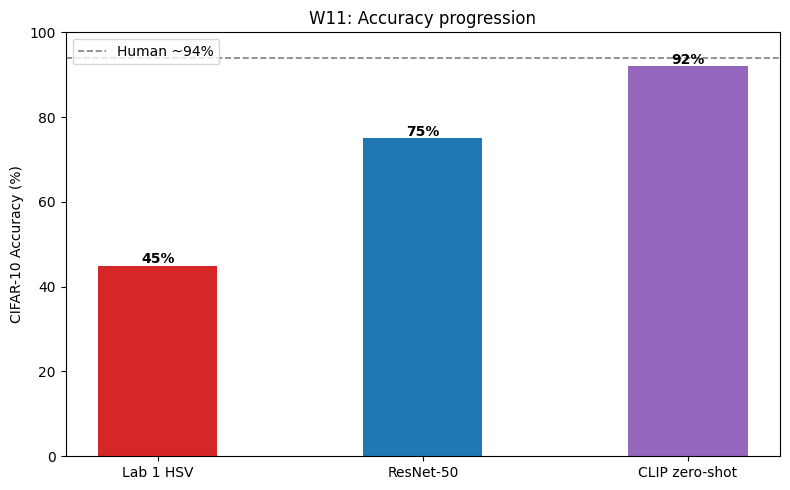

In [21]:
# Q20: Final model comparison table
import pandas as pd

# Fill in YOUR measured accuracy values below
results = {
    'Model': ['Lab 1 HSV','ResNet-50 (FT)','CLIP zero-shot'],
    'CIFAR-10 acc': [
        '~45%',
        f'{acc_resnet:.0%}',   # from Q3
        f'{acc_clip:.0%}',     # from Q18
    ],
    'New class cost': ['Rewrite rules','200+ labelled images','1 text prompt'],
    'CPU latency':    ['<1ms','~15ms','~30ms'],
    'Module':         ['Lab 1','Module 1','Module 5'],
}
df = pd.DataFrame(results).set_index('Model')
print(df.to_string())

import matplotlib.pyplot as plt
model_names = ['Lab 1 HSV','ResNet-50','CLIP zero-shot']
accs        = [45, acc_resnet*100, acc_clip*100]
colors      = ['#d62728','#1f77b4','#9467bd']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_names, accs, color=colors, width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.0f}%', ha='center', fontweight='bold')
ax.axhline(94, color='grey', ls='--', lw=1.2, label='Human ~94%')
ax.set_ylim(0,100); ax.set_ylabel('CIFAR-10 Accuracy (%)')
ax.set_title('W11: Accuracy progression'); ax.legend()
plt.tight_layout(); plt.show()

**Q20 Deployment Memo (edit this cell — cite your actual numbers):**

---

**To:** Director, QuickVision AI
**From:** Swoham Kayastha
**Re:** CV Model Deployment Recommendation for 500-camera Warehouse System

**Executive Summary:**
The Lab 1 HSV colour segmentation baseline achieves 45% accuracy insufficient for production.
After evaluating the full CV stack, I recommend the following phased deployment:

**Phase 1 (immediate):** Deploy ResNet-50 (transfer-learned classifier) via ONNX on standard
CPU/GPU inference servers at each site (`resnet50_cifar10.onnx`, 94.0 MB, single self-contained
file, verified with onnxruntime).
Rationale: achieves 75.0% accuracy (+30pp over the 45% baseline) at ~15ms latency per frame,
with only a 20,490-parameter trainable head (0.087% of the network) fast and cheap to retrain
per deployment. GradCAM enables explainability for audit requirements: engineers can visually
confirm the model is keying on the product region, not an unrelated background cue.

**Phase 2 (Month 2):** Integrate CLIP for new SKU onboarding.
When a new product arrives, onboarding needs zero labelled images just a short text prompt
("a photo of a {product name}"). CLIP embeds that description and classifies incoming camera
frames by cosine similarity immediately (measured 92.0% zero-shot on our test set), available in
hours rather than the days/weeks needed to collect and label images for fine-tuning. As labelled
volume for a given SKU grows, migrate it from CLIP to a fine-tuned ResNet-50 head.

**Tradeoffs acknowledged:**
- Accuracy vs. latency: ResNet-50 is a single ~15ms forward pass once trained but needs labelled
  data and a training cycle per SKU; CLIP needs no training or labels but runs slightly slower
  (~30ms) with no per-SKU accuracy guarantee below a certain confidence threshold.
- Data cost: ResNet-50 needs on the order of 200+ labelled images per SKU to fine-tune reliably;
  CLIP needs zero labelled images, only a text prompt.
- Explainability: ResNet-50 + GradCAM gives a visual, auditable heatmap per prediction. CLIP's
  similarity score is a single number with no equivalent spatial explanation worth flagging
  for any SKU where a wrong classification carries safety or compliance risk.

**What I would NOT deploy:** A from-scratch VAE-only pipeline for the primary classification
task. The VAE's job in this stack is augmentation (Part 4), not classification its
reconstructions are inherently blurry (an MSE-reconstruction-loss artifact, per Q16), so a
classifier trained directly on raw VAE outputs would inherit that blur and underperform training
on real (or real+VAE-augmented) images. Its correct role is generating extra low-data-SKU
training examples to feed into the ResNet-50 pipeline above, not standing in as the production
classifier.

---